In [41]:
import urllib.request
url = ("https://raw.githubusercontent.com/""ilya-pimenov/LLM-Study/refs/heads/main/""the-verdict.txt")

file_path = "the-verdict.txt"

urllib.request.urlretrieve(url, file_path)

with open("the-verdict.txt", "r", encoding="utf-8") as f:raw_text = f.read()
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20480
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [42]:
import torch
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
  def __init__(self, txt, tokenizer, max_length, stride):
    self.input_ids = []
    self.target_ids = []
    token_ids = tokenizer.encode(txt)
    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i:i + max_length]
      target_chunk = token_ids[i + 1:i + max_length + 1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))
  def __len__(self):
    return len(self.input_ids)
  def __getitem__(self, idx):
   return self.input_ids[idx], self.target_ids[idx]

In [43]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
  stride=128, shuffle=True,
  drop_last=True, num_workers=0):
  tokenizer = tiktoken.get_encoding("gpt2")
  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers )
  return dataloader

In [44]:
import torch
import torch.nn as nn
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0)
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads # Corrected: head_dim should be d_out / num_heads
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask",torch.triu(torch.ones(context_length,context_length), diagonal=1))
  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)
    keys = keys.view(b, num_tokens,
    self.num_heads, self.head_dim)
    values = values.view(b, num_tokens,
    self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens,
    self.num_heads, self.head_dim)
    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)
    attn_scores = queries @ keys.transpose(2, 3)
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    attn_scores.masked_fill_(mask_bool, -torch.inf)
    attn_weights = torch.softmax(
    attn_scores / keys.shape[-1]**0.5,
    dim=-1
    )
    attn_weights = self.dropout(attn_weights)
    context_vec = attn_weights @ values
    context_vec = (attn_weights @ values).transpose(1, 2)
    context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
    context_vec = self.out_proj(context_vec) #fine tuning the outputs
    return context_vec

In [45]:
GPT_CONFIG_124M = {
"vocab_size": 50257, # Vocabulary size
"context_length": 1024, # Context length
"emb_dim": 768, # Embedding dimension
"n_heads": 12, # Number of attention heads
"n_layers": 12, # Number of layers
"drop_rate": 0.1, # Dropout rate
"qkv_bias": False # Query-Key-Value bias
}

In [46]:
#torch.manual_seed(42)
#batch_example = torch.randn(2, 5)
#layer = nn.Sequential(
#nn.Linear(5, 6),nn.ReLU())
#out = layer(batch_example)

In [47]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))
  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

In [48]:
#ln = LayerNorm(emb_dim=256)
#out_ln = ln(batch_example)
#mean = out_ln.mean(dim=-1, keepdim=True)
#var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
#print("Mean:\n", mean)
#print("Variance:\n", var)

In [49]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self, x):
    return 0.5 * x * (
    1 + torch.tanh(
    torch.sqrt(torch.tensor(2.0 / torch.pi)) *
    (x + 0.044715 * torch.pow(x, 3))
    )
    )

In [50]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
    nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
    GELU(),
    nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
    )
  def forward(self, x):
   return self.layers(x)

In [51]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.att = MultiHeadAttention(
    d_in=cfg["emb_dim"],
    d_out=cfg["emb_dim"],
    context_length=cfg["context_length"],
    num_heads=cfg["n_heads"],
    dropout=cfg["drop_rate"],
    qkv_bias=cfg["qkv_bias"]
    )
    self.feed_forward = FeedForward(cfg)
    self.ln1 = LayerNorm(cfg["emb_dim"])
    self.ln2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
  def forward(self, x):
    shortcut = x
    x = self.ln1(x)
    x = self.att(x)
    x = self.drop_shortcut(x)
    x = x + shortcut
    shortcut = x
    x = self.ln2(x)
    x = self.feed_forward(x)
    x = self.drop_shortcut(x)
    x = x + shortcut
    return x

In [52]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])
    self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
  def forward(self, in_idx):
   batch_size, seq_len = in_idx.shape
   tok_embeds = self.tok_emb(in_idx)
   pos_embeds = self.pos_emb(
   torch.arange(seq_len, device=in_idx.device))
   x = tok_embeds + pos_embeds
   x = self.drop_emb(x)
   x = self.trf_blocks(x)
   x = self.final_norm(x)
   logits = self.out_head(x)
   return logits

In [53]:
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

In [54]:
def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

In [55]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
  train_losses, val_losses = [], []
  for epoch in range(num_epochs):
    model.train()
    for input_batch, target_batch in train_loader:
      optimizer.zero_grad()
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      loss.backward()
      optimizer.step()
    generate_and_print_sample(model, tokenizer, device, start_context)
  return train_losses, val_losses

In [56]:
def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    token_ids = generate_text_simple(model=model, idx=encoded, max_new_tokens=50, context_size=context_size)
  decoded_text = token_ids_to_text(token_ids, tokenizer)
  print(decoded_text.replace("\n", " "))

  model.train()

In [57]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
  return loss

In [58]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]
    probas = torch.softmax(logits, dim=-1)
    idx_next = torch.argmax(probas, dim=-1, keepdim=True)
    idx = torch.cat((idx, idx_next), dim=1)
  return idx

In [59]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ratio = 0.90
split_idx = int(train_ratio * len(raw_text))
train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]

train_loader = create_dataloader_v1(train_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"], drop_last=True, shuffle=True, num_workers=0)

val_loader = create_dataloader_v1(val_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"], drop_last=False, shuffle=False, num_workers=0 )

In [60]:
torch.manual_seed(42)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
model.parameters(),
lr=0.0004,
weight_decay=0.1
)
num_epochs = 100

train_losses, val_losses = train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs, eval_freq=5, eval_iter=5, start_context="Shamir wants to eat rice", tokenizer=tokenizer)

Shamir wants to eat rice, the, the the the the the, the the the, the the, the the, the the the, the the, the the, the the the, the, the the, the, the, the the the, the the, the
Shamir wants to eat rice, the,,, the,,, the,,,,,,, the,, the,,,,,, the, the, the,,,,,,,,,,,,,, the,,,
Shamir wants to eat rice, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the, the
Shamir wants to eat rice, and, and, and--.                                          
Shamir wants to eat rice. ", the the the. ". ". ". ". ". ". ", the. ". " the the. ". " the the the. "
Shamir wants to eat rice.  "-- of the--.   "-- of the of the  ". "  "-- of the  "--. " "-- "-- "--and, and I
Shamir wants to eat rice. Gisburn--and--and, and I had been of the house was a   "III to the house, and he was, and I had been the of the house of the house the house the house. G
Shamir wants to eat rice--and--and a--and--and a a the of the of a was a--and--and of a that, a

In [61]:
vocab = {
"closer": 0,
"every": 1,
"effort": 2,
"forward": 3,
"inches": 4,
"moves": 5,
"pizza": 6,
"toward": 7,
"you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}
print(inverse_vocab)

next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print("\n",inverse_vocab[next_token_id])

torch.manual_seed(42)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print("\n", inverse_vocab[next_token_id])

{0: 'closer', 1: 'every', 2: 'effort', 3: 'forward', 4: 'inches', 5: 'moves', 6: 'pizza', 7: 'toward', 8: 'you'}

 forward

 forward


In [62]:
def print_sampled_tokens(probas):
  torch.manual_seed(42)
  sample = [torch.multinomial(probas, num_samples=1).item()for i in range(1000)]
  sampled_ids = torch.bincount(torch.tensor(sample))
  for i, freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

67 x closer
2 x every
0 x effort
577 x forward
5 x inches
0 x moves
0 x pizza
345 x toward
4 x you


In [63]:
def softmax_with_temperature(logits, temperature):
  scaled_logits = logits / temperature
  return torch.softmax(scaled_logits, dim=0)

[tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03]), tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22]), tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])]


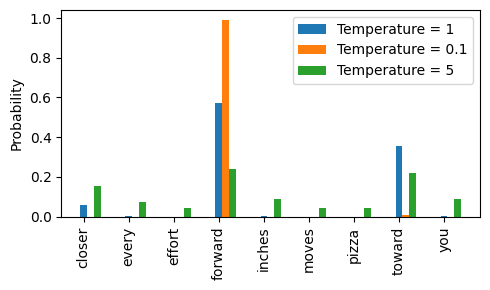

In [64]:
import matplotlib.pyplot as plt
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)for T in temperatures]
print(scaled_probas)

x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))

for i, T in enumerate(temperatures):
  rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width,label=f'Temperature = {T}')
  ax.set_ylabel('Probability')
  ax.set_xticks(x)
  ax.set_xticklabels(vocab.keys(), rotation=90)
  ax.legend()
plt.tight_layout()
plt.show()

In [65]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

new_logits = torch.where(condition=next_token_logits < top_logits[-1], input=torch.tensor(float('-inf')), other=next_token_logits)
print("\n", new_logits)

topk_probas = torch.softmax(new_logits, dim=0)
print("\n", topk_probas)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])

 tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])

 tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [66]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:, -1, :]
    if top_k is not None:
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(logits < min_val, torch.tensor(float('-inf')).to(logits.device), logits)
    if temperature > 0.0:
      logits = logits / temperature
      probs = torch.softmax(logits, dim=-1)
      idx_next = torch.multinomial(probs, num_samples=1)
    else:
      idx_next = torch.argmax(logits, dim=-1, keepdim=True)
    if idx_next == eos_id:
      break
    idx = torch.cat((idx, idx_next), dim=1)
  return idx


torch.manual_seed(42)
token_ids = generate(
model=model,
idx=text_to_token_ids("Shamir wants to eat rice", tokenizer).to(device),
max_new_tokens=15,
context_size=GPT_CONFIG_124M["context_length"],
top_k=25,
temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Shamir wants to eat rice through my surprise, for he answered with a laugh on the background of her


In [67]:
torch.save(model.state_dict(), "model.pth")

#(or)

torch.save({
"model_state_dict": model.state_dict(),
"optimizer_state_dict": optimizer.state_dict(),
}, "model_and_optimizer.pth")

In [68]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (ln1): LayerNorm()
      (ln2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_f

In [69]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (ln1): LayerNorm()
      (ln2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_f

In [70]:
!pip install tensorflow>=2.15.0 tqdm>=4.66

import urllib.request
url = ("https://raw.githubusercontent.com/rasbt/""LLMs-from-scratch/main/ch05/""01_main-chapter-code/gpt_download.py")

filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7f6f98c0f8c0>)

In [71]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

print("\nSettings:", settings)
print("Parameter dictionary keys:", params.keys())

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [72]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)


[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [73]:
model_configs = {
"gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
"gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
"gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
"gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})

In [74]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (ln1): LayerNorm()
      (ln2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feat

In [75]:
def assign(left, right):
  if left.shape != right.shape:
    raise ValueError(f"Shape mismatch. Left: {left.shape}, "f"Right: {right.shape}")
  return torch.nn.Parameter(torch.tensor(right))

In [76]:
import numpy as np

def load_weights_into_gpt(gpt, params):
  gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
  gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
  for b in range(len(params["blocks"])):
    q_w, k_w, v_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
    gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
    gpt.trf_blocks[b].att.W_key.weight = assign(gpt.trf_blocks[b].att.W_key.weight, k_w.T)
    gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)

    q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
    gpt.trf_blocks[b].att.W_query.bias = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
    gpt.trf_blocks[b].att.W_key.bias = assign(gpt.trf_blocks[b].att.W_key.bias, k_b)
    gpt.trf_blocks[b].att.W_value.bias = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)

    gpt.trf_blocks[b].att.out_proj.weight = assign(gpt.trf_blocks[b].att.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
    gpt.trf_blocks[b].att.out_proj.bias = assign(gpt.trf_blocks[b].att.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])

    gpt.trf_blocks[b].feed_forward.layers[0].weight = assign(gpt.trf_blocks[b].feed_forward.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
    gpt.trf_blocks[b].feed_forward.layers[0].bias = assign(gpt.trf_blocks[b].feed_forward.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])
    gpt.trf_blocks[b].feed_forward.layers[2].weight = assign(gpt.trf_blocks[b].feed_forward.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
    gpt.trf_blocks[b].feed_forward.layers[2].bias = assign(gpt.trf_blocks[b].feed_forward.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])

    gpt.trf_blocks[b].ln1.scale = assign(gpt.trf_blocks[b].ln1.scale, params["blocks"][b]["ln_1"]["g"])
    gpt.trf_blocks[b].ln1.shift = assign(gpt.trf_blocks[b].ln1.shift, params["blocks"][b]["ln_1"]["b"])

    gpt.trf_blocks[b].ln2.scale = assign(gpt.trf_blocks[b].ln2.scale, params["blocks"][b]["ln_2"]["g"])
    gpt.trf_blocks[b].ln2.shift = assign(gpt.trf_blocks[b].ln2.shift, params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [77]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

torch.manual_seed(42)
token_ids = generate(model=gpt, idx=text_to_token_ids("Shamir likes to eat mangoes", tokenizer).to(device), max_new_tokens=25, context_size=NEW_CONFIG["context_length"], top_k=50, temperature=1.5)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Shamir likes to eat mangoes for the rest of the week, but this time it would lead to another mango fall if you let off the oil on all


In [78]:
from gpt_download import download_and_load_gpt2

# 1. Set model name to medium
model_name = "gpt2-medium (355M)"

# 2. Update configuration
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

# 3. Download medium weights
settings, params = download_and_load_gpt2(model_size="355M", models_dir="gpt2")

# 4. Initialize and load model
gpt = GPTModel(NEW_CONFIG)
load_weights_into_gpt(gpt, params)
gpt.to(device)
gpt.eval()

# 5. Generate text
torch.manual_seed(42)
token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Shamir likes to eat mangoes", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print(f"Output for {model_name}:\n", token_ids_to_text(token_ids, tokenizer))

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 158kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.93MiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 318kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [02:28<00:00, 9.55MiB/s]
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 14.8MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:00<00:00, 2.69MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.80MiB/s]


Output for gpt2-medium (355M):
 Shamir likes to eat mangoes for the calories that it provides his stomach and a lotus leaves for making his dreams come true.

What you'll
